In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("/Users/sumaiyairshad/Desktop/Data Science Projects/Hospital_Readmission_ML/Data/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.shape

(101766, 50)

In [3]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [6]:
df['readmitted'].value_counts()

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

In [7]:
#CHECKING NULL VALUES

df.isnull().sum()


#It shows no null values but I clearly see '?' everywhere..so lets replace '?' with NAN

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [8]:
##It shows no null values but I clearly see '?' everywhere..so lets replace '?' with NAN

(df == '?').sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of         encounter_id  patient_nbr   race  gender    age  weight  \
0              False        False  False   False  False    True   
1              False        False  False   False  False    True   
2              False        False  False   False  False    True   
3              False        False  False   False  False    True   
4              False        False  False   False  False    True   
...              ...          ...    ...     ...    ...     ...   
101761         False        False  False   False  False    True   
101762         False        False  False   False  False    True   
101763         False        False  False   False  False    True   
101764         False        False  False   False  False    True   
101765         False        False  False   False  False    True   

        admission_type_id  discharge_disposition_id  admission_source_id  \
0                   False                     False      

In [9]:
#CLEANING DATA
#REPLACING '?' WITH "NaN"

df.replace("?",np.nan, inplace=True)

In [10]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
#DROPPING COLUMNS BY CHECKING COLUMNS WITH MISSING VALUES RATIO/ DOMAIN RELEVANCE/POTENTIAL PREDICTIVE IMPACT

df.drop(['weight','payer_code','medical_specialty','race'], axis=1,inplace=True)


In [12]:
df.shape


(101766, 46)

In [13]:
df.isnull().sum()

encounter_id                   0
patient_nbr                    0
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
diag_1                        21
diag_2                       358
diag_3                      1423
number_diagnoses               0
max_glu_serum                  0
A1Cresult                      0
metformin                      0
repaglinide                    0
nateglinide                    0
chlorpropamide                 0
glimepiride                    0
acetohexamide                  0
glipizide                      0
glyburide                      0
tolbutamide                    0
pioglitazone                   0
rosiglitaz

In [14]:

#REPLACING MISSING VALUES OF THE REMAINING COLUMNS WITH MODE AS THEY ARE CATEGORICAL COLUMNS.


df['diag_1'].fillna(df['diag_1'].mode()[0], inplace=True)
df['diag_2'].fillna(df['diag_2'].mode()[0], inplace=True)
df['diag_3'].fillna(df['diag_3'].mode()[0], inplace=True)


In [15]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [16]:
df['readmitted']

0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101766, dtype: object

In [17]:
#WE'll CONVERT TARGET VARIABLE(READMITTED) INTO NUMERICAL COLUMN
#WE HAVE <30,>30 AND NO..SO WE'LL CONVERT
#1== PATEINT READMITTED WITHIN 30 DAYS  & 0== OTHERWISE


df['readmitted']= df['readmitted'].apply(lambda x: 1 if x=='<30' else 0)

In [18]:
df['readmitted'].value_counts()


#This means 90409 patients not readmitted quickly and 11357 patients got readmitted within 30 days'

#THIS ALSO SHOWS DATA IS IMBALANCED

0    90409
1    11357
Name: readmitted, dtype: int64

In [19]:
#NOW WE HAVE 2331 COULMNS WHICH ISNOT GOOD FOR DATA SO I'L DROP DIAG_1,2,3 COLUMNS
#AS IT HAS CREATED THE MOST DUMMIES

df.drop(['diag_1','diag_2','diag_3'], axis=1, inplace=True)

In [20]:
#CONVERTING CATEGORICAL DATA INTO NUMERICAL DATA

df= pd.get_dummies(df,drop_first=True)

In [22]:
df.shape

(101766, 81)

In [23]:
#LET'S TRAIN THE MODEL NOW

from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
X_train.shape, X_test.shape

((81412, 80), (20354, 80))

In [25]:
y_train.shape, y_test.shape

((81412,), (20354,))

In [26]:
#BUILDING ML MODEL
#TRAINING LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [27]:
#MAKING PREDICTIONS
y_pred = model.predict(X_test)

In [28]:
#MODEL EVALUATION

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.887737054141692
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.00      0.00      0.00      2285

    accuracy                           0.89     20354
   macro avg       0.44      0.50      0.47     20354
weighted avg       0.79      0.89      0.83     20354



/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

In [ ]:
#BASICALLY IT IS SAYING NOBODY WILL BE READMITTED
#WHY THIS HAPPENED? BECAUSE WE HAD 90%= CLASS 0 AND 10% CLASS 1
#SO MODEL PREDICTED EVERYTHING AS ZERO AND GAVE HIGH ACCURACY
#BASICALLY THIS MODEL IS USELESS FOR DETECTING RISKY PATIENTS,IGNORING MINORITY CLASS,
#AND NOT SUITABLE FOR HEALTHCARE USE.
#SO MODEL SHOWED HIGH ACCURACY BUT FAILED TO INCLUDE MINORITY CLASS BECAUSE OF CLASS IMBALANCE


#WHAT CAN WE DO TO FIX IT.?WE CAN ADD CLASS WEIGHT
#(BASICALLY,TELL THE MODEL THAT YOUHAVE TO TAKE CARE OF MINORITY CLASS ALSO)

In [29]:
#LETS ADD CLASS WEIGHT

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
#EVALUATION REPORT

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.60      0.72     18069
           1       0.12      0.41      0.18      2285

    accuracy                           0.58     20354
   macro avg       0.50      0.51      0.45     20354
weighted avg       0.80      0.58      0.66     20354



In [ ]:
#NOW WE SEE ACCURACY DROPPED FROM 89% TO 58 %
#BECAUSE NOW THE MODEL IS TRYING TO DETECT CLASS 1 ALSO
#NOW WE HAVE TWO MODELS 
#1.MODEL A(WITHOUT CLASS WEIGHT) AND 2.MODEL B(WITH CLASS WEIGHT)
#MODEL A HAS HIGH ACCURACY BUT MISSES ALL RISKY PATIENTS 
#WHEREAS MODEL B HAS 58% ACCURACY BUT DETECTS 41% RISKY PATIENTS HENCE MODEL B IS BETTER
#AND HOSPITALS WILL ALSO CHOOOSE MODEL B.

#FINAL CONCLUSION:
#INITIAL MODEL SUFFERED FROM CLASS IMBALANCE.
#AFTER APPLYING CLASS WEIGHT, RECALL FOR MINORITY CLASS IMPROVED SIGNIFICANTLY,
#MAKING THE MODEL MORE USEFUL FOR IDENTIFYING HIGH-RISK PATIENTS.

In [31]:
#EXTRACTING FEATURE IMPORTANCE

import pandas as pd

feature_importance = pd.Series(model.coef_[0], index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

patient_nbr                 1.520900e-09
num_lab_procedures          2.877336e-15
num_medications             1.927553e-15
discharge_disposition_id    1.501110e-15
number_inpatient            1.113944e-15
time_in_hospital            7.616480e-16
number_diagnoses            6.451797e-16
number_emergency            3.193920e-16
admission_source_id         2.430685e-16
number_outpatient           1.246560e-16
dtype: float64

In [ ]:
#THIS SHOWS patient_nbr as the first important feature which might be wrong as it isjust an id.
#and it should not have any influence in prediction.
#This is data leakage or meaningless feature influence
#LET'S DROP THIS COLUMN AND AND DO THE TRAINING AGAIN



In [32]:
#DROPPING patient_nbr column

df.drop(['patient_nbr'], axis=1, inplace=True)

In [33]:
#train-test split

from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
#training model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [35]:
#PREDICTIONS

y_pred = model.predict(X_test)

In [36]:
#EVALUATION

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.00      0.00      0.00      2285

    accuracy                           0.89     20354
   macro avg       0.44      0.50      0.47     20354
weighted avg       0.79      0.89      0.83     20354



/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sumaiyairshad/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

In [37]:
#FEATURE IMPORTANCE

import pandas as pd

feature_importance = pd.Series(model.coef_[0], index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

num_lab_procedures          1.446938e-16
num_medications             9.444867e-17
discharge_disposition_id    7.323036e-17
number_inpatient            5.452513e-17
time_in_hospital            3.774461e-17
number_diagnoses            3.196441e-17
number_emergency            1.562433e-17
admission_source_id         1.271628e-17
number_outpatient           6.120559e-18
diabetesMed_Yes             3.555469e-18
dtype: float64

In [ ]:
#FINAL ANALYSIS
#MOST IMPORTANT FEATURES AND WHAT THEY TELL
#1.num_lab_procedures--MORE TESTS MEANS SERIOUS CONDITION-- HIGHER CHANCE OF READMISSION
#2.num_medications--MORE MEDICINES--COMPLICATED TREATMENT--HIGHER RISK OF READMISSION
#3.time_in_hospital--LONGER STAY--MEANS PATIENT UNSTABLE--HIGHER RISK OF READMISSION
#4.number_inpatient--PREVIOUS HOSPITAL VISITS--STRONGEST REAL-WORLD INDICATOR OF FUTURE VISITS
#5.number_diagnoses--MORE DIAGNOSES--MULTIPLE HEALTH ISSUES--INCREASED RISK OF READMISSION

#FINAL CONCLUSION:
#Key predictors included number of lab procedures, medications, and inpatient visits, indicating that patient complexity and prior hospital 
#interactions are strong drivers of readmission risk.”

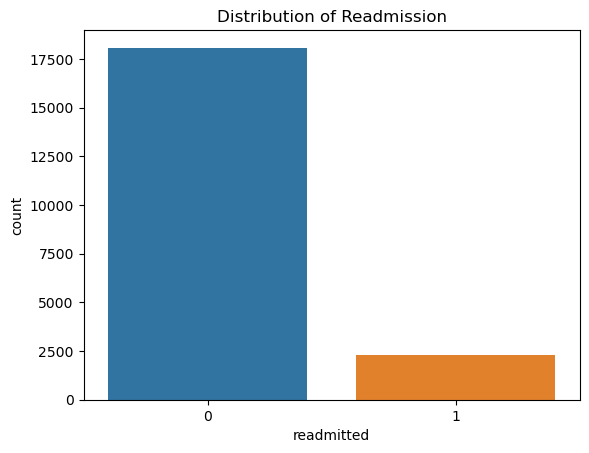

In [38]:
#VISUALIZATION

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_test)
plt.title("Distribution of Readmission")
plt.show()

In [ ]:
#CONCLUSION FROM PLOT
#The dataset exhibited significant class imbalance, with a much higher proportion of non-readmitted patients. 
#This required handling using class weighting to improve minority class detection.”